# BRCA Subtype Classification with GNN
## Master Thesis — BioGNN pipeline

In [1]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split

from src.data_loader import build_graph_dataset
from src.model import BioGNN

c:\Users\danie\Desktop\Master_Thesis_GNN\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# --- 1. PATHS ---
CLINICAL_FILE  = 'data/brca_tcga_pan_can_atlas_2018_clinical_data.tsv'
EXPRESSION_FILE = 'data/mRNA_expression_fixed.txt'

# --- 2. LOAD & ALIGN ---
print('Loading data...')
clinical_df = pd.read_csv(CLINICAL_FILE, sep='\t', comment='#').dropna(subset=['Subtype'])
exp_df      = pd.read_csv(EXPRESSION_FILE, sep='\t')

# Find common samples (intersection)
common_samples = sorted(set(clinical_df['Sample ID']) & set(exp_df['SAMPLE_ID']))
print(f'Common patients found: {len(common_samples)}')

# Build expression matrix: genes as rows, patients as columns (sorted order)
exp_final = (
    exp_df[exp_df['SAMPLE_ID'].isin(common_samples)]
    .set_index('SAMPLE_ID')
    .drop(columns=['STUDY_ID'])
    .T                       # genes x patients
)[common_samples]            # enforce same order

# Clinical data aligned to same order
clinical_final = (
    clinical_df[clinical_df['Sample ID'].isin(common_samples)]
    .set_index('Sample ID')
    .loc[common_samples]     # same order as exp_final
)

print(f'Expression matrix shape: {exp_final.shape}  (genes x patients)')
print(f'Genes: {exp_final.index.tolist()}')
print(f'Subtype distribution:\n{clinical_final["Subtype"].value_counts()}')

Loading data...
Common patients found: 981
Expression matrix shape: (27, 981)  (genes x patients)
Genes: ['TP53', 'BCL2', 'BIRC5', 'BRCA1', 'BRCA2', 'CCNE1', 'CDH1', 'CDK4', 'CDKN2A', 'EGFR', 'ERBB2', 'ESR1', 'FGFR1', 'FOXA1', 'GATA3', 'IGF1R', 'KMT2C', 'KRAS', 'MAP3K1', 'MDM2', 'MET', 'MKI67', 'MYC', 'NF1', 'PIK3CA', 'PTEN', 'RB1']
Subtype distribution:
Subtype
BRCA_LumA      499
BRCA_LumB      197
BRCA_Basal     171
BRCA_Her2       78
BRCA_Normal     36
Name: count, dtype: int64


In [3]:
# --- 3. BUILD PPI from STRING-DB ---
ppi_raw = pd.read_csv('data/string_interactions_short.tsv', sep='\t')
ppi_raw = ppi_raw.rename(columns={'#node1': 'node1'})

# Keep only high-confidence interactions (score >= 0.4 out of 1.0)
ppi_df = ppi_raw[ppi_raw['combined_score'] >= 0.4][['node1', 'node2']].reset_index(drop=True)
print(f'Real STRING-DB edges (score >= 0.4): {len(ppi_df)}')

print('Building graph objects...')
dataset, encoder = build_graph_dataset(exp_final, ppi_df, clinical_final)
print(f'Total graphs (patients): {len(dataset)}')

Real STRING-DB edges (score >= 0.4): 312
Building graph objects...
Classes: ['BRCA_Basal', 'BRCA_Her2', 'BRCA_LumA', 'BRCA_LumB', 'BRCA_Normal']
Graph edges: 570
Total graphs (patients): 981


In [ ]:
# --- 2b. METABRIC DATA AUGMENTATION ---
# Зареждаме предварително изтеглените METABRIC данни (27 гена, 1756 пациента)
meta_expr = pd.read_csv('data/metabric_expression.csv', index_col=0)   # genes x patients
meta_clin = pd.read_csv('data/metabric_clinical.csv', index_col=0)       # patients x [Subtype]

# Гарантираме еднакъв ред на гените
meta_expr = meta_expr.loc[exp_final.index]   # само гените от TCGA, в същия ред

# Обединяваме двете матрици (axis=1 = добавяме нови колони/пациенти)
exp_combined  = pd.concat([exp_final, meta_expr], axis=1)
clin_combined = pd.concat([clinical_final[['Subtype']], meta_clin[['Subtype']]])

print(f'TCGA пациенти:     {exp_final.shape[1]}')
print(f'METABRIC пациенти: {meta_expr.shape[1]}')
print(f'Общо пациенти:     {exp_combined.shape[1]}')
print(f'\nРазпределение на подтиповете (комбинирано):')
print(clin_combined['Subtype'].value_counts())

# Преизграждаме dataset-а с комбинираните данни
print('\nИзграждаме графовете...')
dataset_aug, encoder_aug = build_graph_dataset(exp_combined, ppi_df, clin_combined)
print(f'Общо графове: {len(dataset_aug)}')

In [4]:
# --- 4. K-FOLD CROSS-VALIDATION SETUP ---
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Class weights (inverse frequency)
counts  = clinical_final['Subtype'].value_counts().sort_index().values
weights = 1.0 / torch.tensor(counts, dtype=torch.float)
weights = weights / weights.sum() * len(counts)
print(f'Class weights: { {c: round(w,3) for c,w in zip(encoder.classes_, weights.tolist())} }')

# Labels array for stratification
all_labels_arr = [g.y.item() for g in dataset]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_accuracies = []
fold_f1s        = []
best_acc        = 0.0
best_model_state = None

print(f'\nStarting 5-Fold Cross-Validation...\n')

Using device: cpu
Class weights: {'BRCA_Basal': 0.546, 'BRCA_Her2': 1.198, 'BRCA_LumA': 0.187, 'BRCA_LumB': 0.474, 'BRCA_Normal': 2.595}

Starting 5-Fold Cross-Validation...



In [5]:
# --- 5. K-FOLD TRAINING LOOP ---
indices = list(range(len(dataset)))

for fold, (train_idx, test_idx) in enumerate(skf.split(indices, all_labels_arr), 1):
    print(f'--- Fold {fold}/5 ---')

    train_data   = [dataset[i] for i in train_idx]
    test_data    = [dataset[i] for i in test_idx]
    train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
    test_loader  = DataLoader(test_data,  batch_size=16, shuffle=False)

    # Fresh model for each fold
    model     = BioGNN(num_node_features=1, hidden_channels=64,
                       num_classes=len(encoder.classes_)).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    criterion = torch.nn.CrossEntropyLoss(weight=weights.to(device))

    # Train 100 epochs
    for epoch in range(1, 101):
        model.train()
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            out  = model(batch.x, batch.edge_index, batch.batch)
            loss = criterion(out, batch.y)
            loss.backward()
            optimizer.step()

    # Evaluate on test fold
    model.eval()
    fold_preds, fold_true = [], []
    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device)
            out   = model(batch.x, batch.edge_index, batch.batch)
            fold_preds.extend(out.argmax(dim=1).cpu().numpy())
            fold_true.extend(batch.y.cpu().numpy())

    acc    = sum(p == t for p, t in zip(fold_preds, fold_true)) / len(fold_true)
    macro_f1 = f1_score(fold_true, fold_preds, average='macro', zero_division=0)
    fold_accuracies.append(acc)
    fold_f1s.append(macro_f1)
    print(f'  Accuracy: {acc:.4f}  |  Macro F1: {macro_f1:.4f}')

    # Save best model
    if acc > best_acc:
        best_acc = acc
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        print(f'  --> New best model saved (acc={best_acc:.4f})')

# Save best weights to disk
torch.save(best_model_state, 'best_model.pt')

print(f'\n=== 5-Fold Results ===')
print(f'Accuracy:  {sum(fold_accuracies)/5:.4f}  (+/- {pd.Series(fold_accuracies).std():.4f})')
print(f'Macro F1:  {sum(fold_f1s)/5:.4f}  (+/- {pd.Series(fold_f1s).std():.4f})')
print(f'Best fold accuracy: {best_acc:.4f}')
print(f'Best model saved to: best_model.pt')

--- Fold 1/5 ---
  Accuracy: 0.5482  |  Macro F1: 0.4321
  --> New best model saved (acc=0.5482)
--- Fold 2/5 ---
  Accuracy: 0.6276  |  Macro F1: 0.5061
  --> New best model saved (acc=0.6276)
--- Fold 3/5 ---
  Accuracy: 0.5255  |  Macro F1: 0.4267
--- Fold 4/5 ---
  Accuracy: 0.5255  |  Macro F1: 0.4509
--- Fold 5/5 ---
  Accuracy: 0.6020  |  Macro F1: 0.4799

=== 5-Fold Results ===
Accuracy:  0.5658  (+/- 0.0466)
Macro F1:  0.4591  (+/- 0.0335)
Best fold accuracy: 0.6276
Best model saved to: best_model.pt


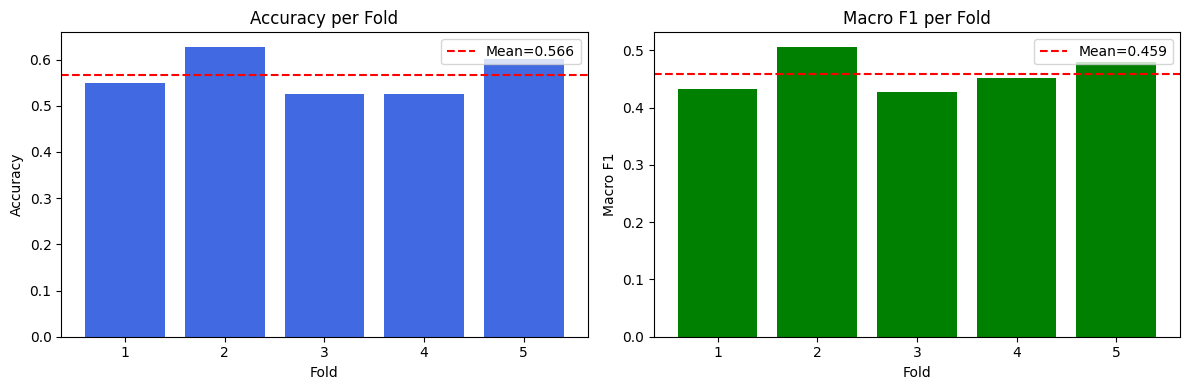

Plot saved to training_curves.png


In [6]:
# --- 6. VISUALISE FOLD RESULTS ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

folds = range(1, 6)
ax1.bar(folds, fold_accuracies, color='royalblue')
ax1.axhline(sum(fold_accuracies)/5, color='red', linestyle='--', label=f'Mean={sum(fold_accuracies)/5:.3f}')
ax1.set_xlabel('Fold'); ax1.set_ylabel('Accuracy')
ax1.set_title('Accuracy per Fold'); ax1.legend()

ax2.bar(folds, fold_f1s, color='green')
ax2.axhline(sum(fold_f1s)/5, color='red', linestyle='--', label=f'Mean={sum(fold_f1s)/5:.3f}')
ax2.set_xlabel('Fold'); ax2.set_ylabel('Macro F1')
ax2.set_title('Macro F1 per Fold'); ax2.legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()
print('Plot saved to training_curves.png')

In [ ]:
# --- 5b. 5-FOLD CV С METABRIC AUGMENTATION ---
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

counts_aug  = clin_combined['Subtype'].value_counts().sort_index().values
weights_aug = 1.0 / torch.tensor(counts_aug, dtype=torch.float)
weights_aug = weights_aug / weights_aug.sum() * len(counts_aug)
print(f'Class weights (augmented): { {c: round(w,3) for c,w in zip(encoder_aug.classes_, weights_aug.tolist())} }')

all_labels_aug = [g.y.item() for g in dataset_aug]
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_acc_aug, fold_f1_aug = [], []
best_acc_aug, best_state_aug = 0.0, None

print('\nStarting 5-Fold CV (TCGA + METABRIC)...\n')
indices_aug = list(range(len(dataset_aug)))

for fold, (train_idx, test_idx) in enumerate(skf.split(indices_aug, all_labels_aug), 1):
    print(f'--- Fold {fold}/5 ---')
    train_data   = [dataset_aug[i] for i in train_idx]
    test_data    = [dataset_aug[i] for i in test_idx]
    train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
    test_loader  = DataLoader(test_data,  batch_size=32, shuffle=False)

    model_aug = BioGNN(num_node_features=1, hidden_channels=64,
                       num_classes=len(encoder_aug.classes_)).to(device)
    optimizer = torch.optim.Adam(model_aug.parameters(), lr=0.001, weight_decay=1e-4)
    criterion = torch.nn.CrossEntropyLoss(weight=weights_aug.to(device))

    for epoch in range(1, 101):
        model_aug.train()
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            out  = model_aug(batch.x, batch.edge_index, batch.batch)
            loss = criterion(out, batch.y)
            loss.backward()
            optimizer.step()

    model_aug.eval()
    preds, trues = [], []
    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device)
            out   = model_aug(batch.x, batch.edge_index, batch.batch)
            preds.extend(out.argmax(dim=1).cpu().numpy())
            trues.extend(batch.y.cpu().numpy())

    acc      = sum(p == t for p, t in zip(preds, trues)) / len(trues)
    macro_f1 = f1_score(trues, preds, average='macro', zero_division=0)
    fold_acc_aug.append(acc)
    fold_f1_aug.append(macro_f1)
    print(f'  Accuracy: {acc:.4f}  |  Macro F1: {macro_f1:.4f}')

    if acc > best_acc_aug:
        best_acc_aug   = acc
        best_state_aug = {k: v.clone() for k, v in model_aug.state_dict().items()}
        print(f'  --> New best model (acc={best_acc_aug:.4f})')

torch.save(best_state_aug, 'best_model_augmented.pt')

print(f'\n=== Резултати (TCGA + METABRIC) ===')
print(f'Accuracy:  {sum(fold_acc_aug)/5:.4f}  (+/- {pd.Series(fold_acc_aug).std():.4f})')
print(f'Macro F1:  {sum(fold_f1_aug)/5:.4f}  (+/- {pd.Series(fold_f1_aug).std():.4f})')
print(f'Best fold: {best_acc_aug:.4f}')
print(f'\n=== Сравнение: Преди vs. След Augmentation ===')
print(f'Accuracy:  {sum(fold_accuracies)/5:.4f}  -->  {sum(fold_acc_aug)/5:.4f}')
print(f'Macro F1:  {sum(fold_f1s)/5:.4f}  -->  {sum(fold_f1_aug)/5:.4f}')

In [7]:
# --- 7. PER-CLASS REPORT (best model on full dataset) ---
from sklearn.metrics import classification_report

model.load_state_dict(best_model_state)
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for batch in DataLoader(dataset, batch_size=32):
        batch = batch.to(device)
        out   = model(batch.x, batch.edge_index, batch.batch)
        all_preds.extend(out.argmax(dim=1).cpu().numpy())
        all_labels.extend(batch.y.cpu().numpy())

print('Classification Report (best model):')
print(classification_report(all_labels, all_preds,
                             target_names=encoder.classes_, zero_division=0))

Classification Report (best model):
              precision    recall  f1-score   support

  BRCA_Basal       0.69      0.71      0.70       171
   BRCA_Her2       0.33      0.51      0.40        78
   BRCA_LumA       0.76      0.66      0.71       499
   BRCA_LumB       0.41      0.40      0.41       197
 BRCA_Normal       0.16      0.28      0.20        36

    accuracy                           0.59       981
   macro avg       0.47      0.51      0.48       981
weighted avg       0.62      0.59      0.60       981



In [ ]:
# --- 7b. PER-CLASS REPORT (augmented model, тест само върху TCGA) ---
from sklearn.metrics import classification_report

model_aug.load_state_dict(best_state_aug)
model_aug.eval()

# Тестваме само върху оригиналните TCGA пациенти (честен тест)
tcga_only = dataset_aug[:len(dataset)]
all_preds_aug, all_labels_aug_list = [], []
with torch.no_grad():
    for batch in DataLoader(tcga_only, batch_size=32):
        batch = batch.to(device)
        out   = model_aug(batch.x, batch.edge_index, batch.batch)
        all_preds_aug.extend(out.argmax(dim=1).cpu().numpy())
        all_labels_aug_list.extend(batch.y.cpu().numpy())

print('Classification Report — Augmented model (тест само върху TCGA):')
print(classification_report(all_labels_aug_list, all_preds_aug,
                             target_names=encoder_aug.classes_, zero_division=0))

Стартиране на t-SNE... Моля, изчакайте.


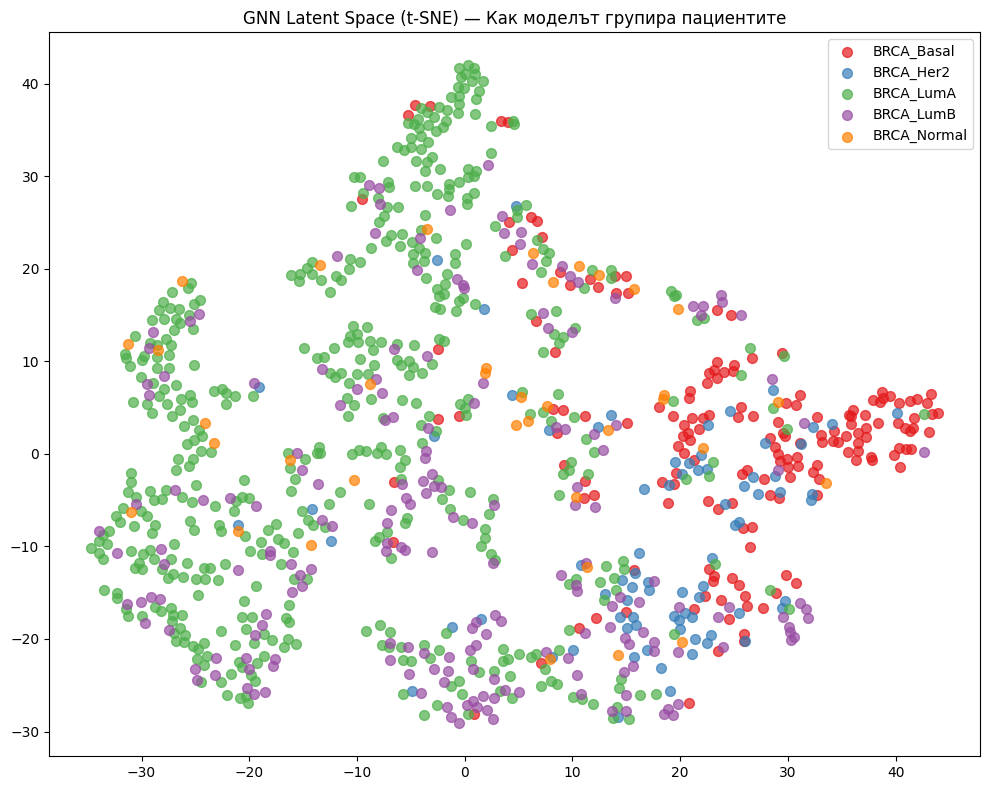

✅ Всичко е готово! Графиката е запазена като gnn_latent_space.png


In [8]:
# --- 8. INSIGHTS: Генериране на Ембединги и t-SNE Визуализация ---
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from torch_geometric.loader import DataLoader

# 8a. Извличане на ембедингите (скритото знание на модела)
latent_vecs = []
labels_list = []

# Използваме "кука" (hook), за да вземем данните преди последния слой
def hook_fn(module, input, output):
    # input[0] съдържа вектора след обединяването (global_mean_pool)
    latent_vecs.append(input[0].detach().cpu().numpy())

# Закачаме куката за линейния слой на модела
handle = model.lin.register_forward_hook(hook_fn)

model.eval()
with torch.no_grad():
    for batch in DataLoader(dataset, batch_size=32):
        batch = batch.to(device)
        model(batch.x, batch.edge_index, batch.batch)
        labels_list.extend(batch.y.cpu().numpy())

handle.remove() # Важно: махаме куката след работа

# Сглобяваме финалните масиви
embeddings = np.vstack(latent_vecs)
labels_arr = np.array(labels_list)

# 8b. t-SNE визуализация (Намаляване на измеренията)
print("Стартиране на t-SNE... Моля, изчакайте.")
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
coords = tsne.fit_transform(embeddings)

# 8c. Чертане на графиката
fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']
for i, name in enumerate(encoder.classes_):
    idx = np.where(labels_arr == i)
    ax.scatter(coords[idx, 0], coords[idx, 1], label=name,
               color=colors[i] if i < len(colors) else None, alpha=0.7, s=50)

ax.set_title('GNN Latent Space (t-SNE) — Как моделът групира пациентите')
ax.legend()
plt.tight_layout()
plt.savefig('gnn_latent_space.png', dpi=150)
plt.show()

print('✅ Всичко е готово! Графиката е запазена като gnn_latent_space.png')

In [9]:
# --- 4. TRAIN / TEST SPLIT ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

train_data, test_data = train_test_split(dataset, test_size=0.2, random_state=42)
train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=16, shuffle=False)

model     = BioGNN(num_node_features=1, hidden_channels=64,
                   num_classes=len(encoder.classes_)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# Class weights — inverse frequency so rare subtypes (Her2, Normal) get more attention
counts  = clinical_final['Subtype'].value_counts().sort_index().values
weights = 1.0 / torch.tensor(counts, dtype=torch.float)
weights = weights / weights.sum() * len(counts)  # normalise
criterion = torch.nn.CrossEntropyLoss(weight=weights.to(device))
print(f'Class weights: { {c: round(w, 3) for c, w in zip(encoder.classes_, weights.tolist())} }')

Using device: cpu
Class weights: {'BRCA_Basal': 0.546, 'BRCA_Her2': 1.198, 'BRCA_LumA': 0.187, 'BRCA_LumB': 0.474, 'BRCA_Normal': 2.595}
